In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity
from sklearn.metrics import mean_squared_error

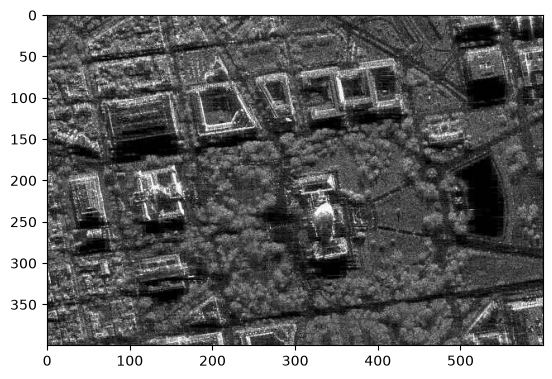

In [13]:
image_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image_gray, cmap='gray')
plt.show()

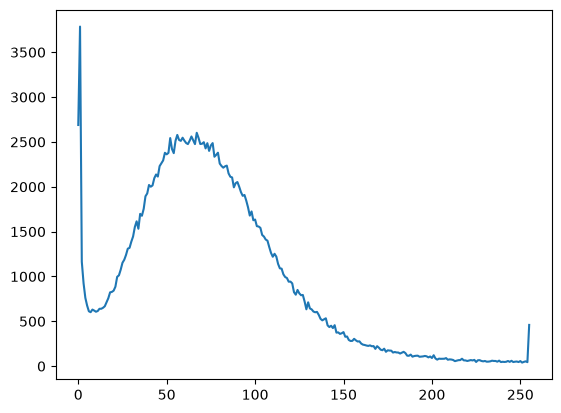

In [8]:
hist = cv2.calcHist([image_gray], [0], None, [256], [0,256])
plt.plot(hist)

In [16]:
def gamma_correction(img, gamma):
    img = img / 255.0
    corrected = np.power(img, gamma)
    return (corrected * 255).astype(np.uint8)

gamma_light = gamma_correction(image_gray, 0.5)
gamma_dark  = gamma_correction(image_gray, 1.5)

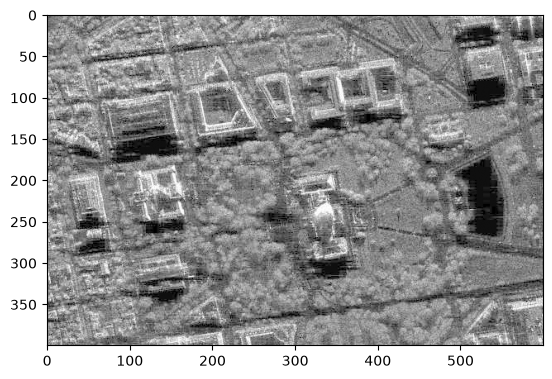

In [17]:
plt.imshow(gamma_light, cmap='gray')
plt.show()

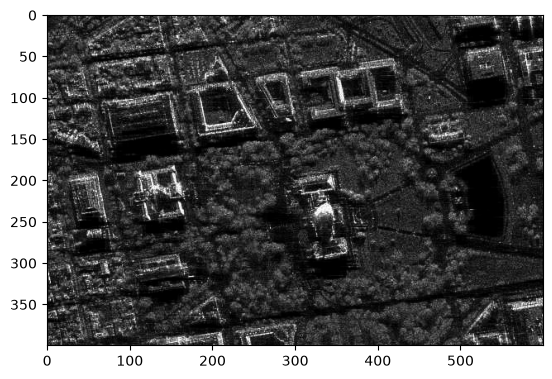

In [18]:
plt.imshow(gamma_dark, cmap='gray')
plt.show()

In [22]:
(ssim, diff) = structural_similarity(image_gray, gamma_light, full=True)
diff = (diff * 255).astype("uint8")
mse = mean_squared_error(image_gray, gamma_light)
print("SSIM: {}".format(ssim))
print("MSE: {}".format(mse))

SSIM: 0.7875008686792752
MSE: 3250.429145833333


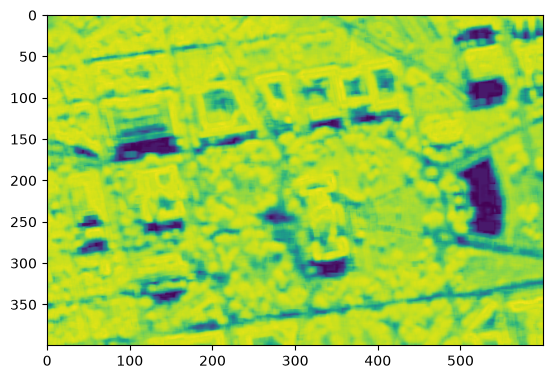

In [23]:
plt.imshow(diff)


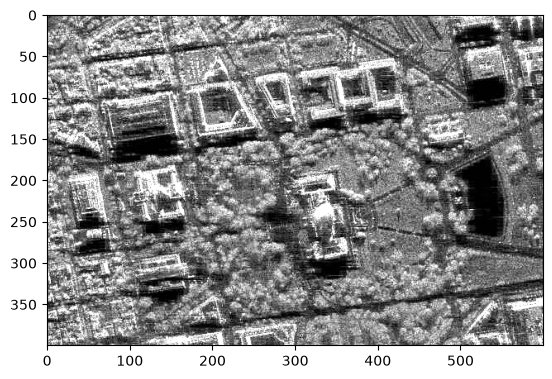

In [25]:
eq_gray = cv2.equalizeHist(image_gray)

E_t = image_gray.mean()
D_t = image_gray.std()
E_s = eq_gray.mean()
D_s = eq_gray.std()
image_corrected = (E_s + (image_gray - E_t) * (D_s / D_t)).clip(0, 255)

plt.imshow(image_corrected, cmap='gray')
plt.show()

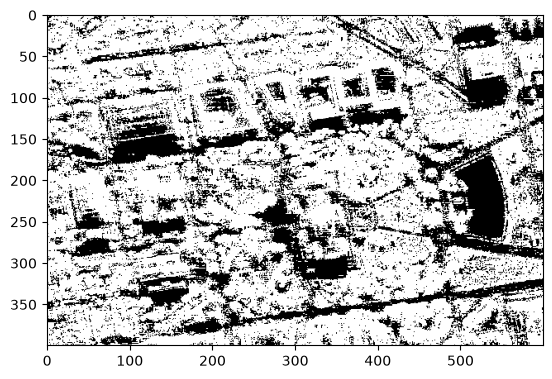

In [28]:
_,thresh1 = cv2.threshold(image_gray,50,255,cv2.THRESH_BINARY)
plt.imshow(thresh1, cmap='gray')
plt.show()

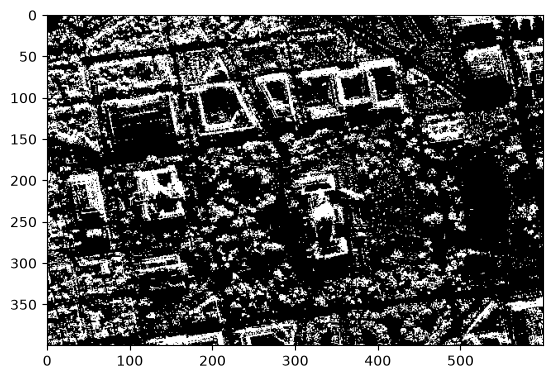

In [29]:
_,thresh2 = cv2.threshold(image_gray,100,255,cv2.THRESH_BINARY)
plt.imshow(thresh2, cmap='gray')
plt.show()

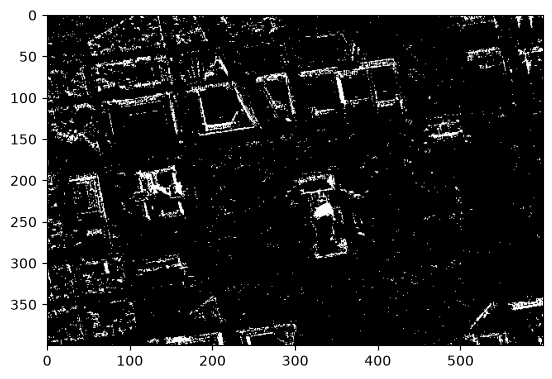

In [30]:
_,thresh3 = cv2.threshold(image_gray,150,255,cv2.THRESH_BINARY)
plt.imshow(thresh3, cmap='gray')
plt.show()

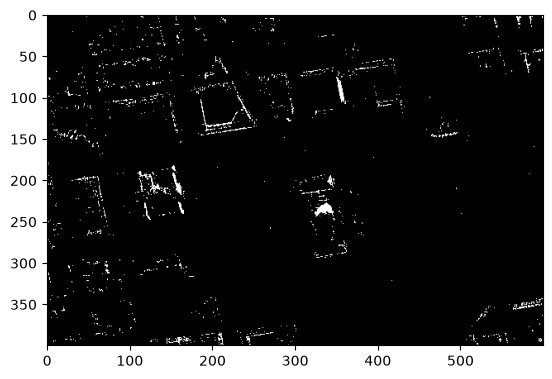

In [31]:
_,thresh4 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)
plt.imshow(thresh4, cmap='gray')
plt.show()